✅ Filtered features loaded
Filtered rows: 4564
Filtered columns: 96

✅ Original dataset loaded
Original rows: 4719

✅ Bandgap column: Bandgap

✅ Rows matched
Rows used for analysis: 4564

✅ Bandgap target added
Rows after removing missing Bandgap: 4564

Number of numeric features: 96
Features after cleaning: 96
Number of features to select: 20

SELECTED FEATURES
1 MagpieData maximum Electronegativity
2 MagpieData mean Electronegativity
3 MagpieData minimum NsValence
4 MagpieData maximum NsValence
5 MagpieData mean NsValence
6 MagpieData mode NsValence
7 MagpieData minimum NpUnfilled
8 MagpieData maximum NpUnfilled
9 MagpieData avg_dev NpUnfilled
10 MagpieData minimum NdUnfilled
11 MagpieData maximum NdUnfilled
12 MagpieData minimum NUnfilled
13 MagpieData maximum NUnfilled
14 MagpieData range NUnfilled
15 MagpieData mean NUnfilled
16 MagpieData avg_dev NUnfilled
17 MagpieData minimum GSmagmom
18 MagpieData maximum GSmagmom
19 MagpieData range GSmagmom
20 MagpieData mean GSmagmom

✅ Fil

,Feature,Ranking
36,MagpieData minimum NsValence,1
68,MagpieData maximum NdUnfilled,1
67,MagpieData minimum NdUnfilled,1
65,MagpieData avg_dev NpUnfilled,1
62,MagpieData maximum NpUnfilled,1
61,MagpieData minimum NpUnfilled,1
73,MagpieData maximum NUnfilled,1
74,MagpieData range NUnfilled,1
75,MagpieData mean NUnfilled,1
76,MagpieData avg_dev NUnfilled,1


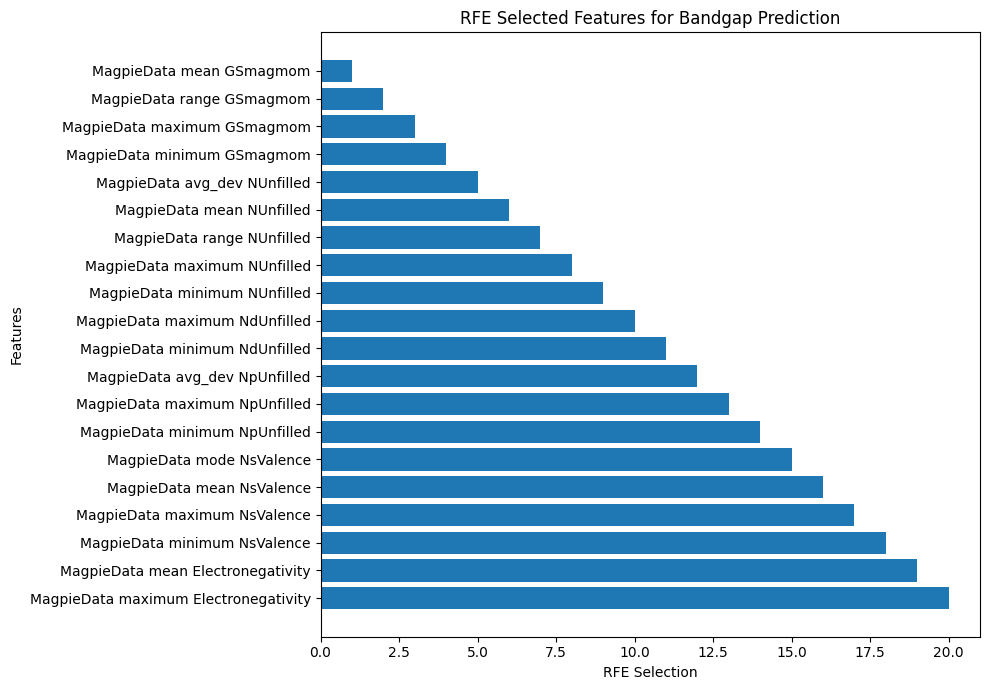


🎉 SESSION 21 COMPLETED SUCCESSFULLY!


In [1]:
# ============================================================
# SESSION 21 - RFE FEATURE SELECTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge


# ------------------------------------------------------------
# 1. Load filtered features from Session 20
# ------------------------------------------------------------

df_features = pd.read_csv("filtered_features_s20.csv")

print("✅ Filtered features loaded")
print("Filtered rows:", len(df_features))
print("Filtered columns:", len(df_features.columns))


# ------------------------------------------------------------
# 2. Load original dataset
# ------------------------------------------------------------

df_original = pd.read_csv("perovskites_data.csv")

print("\n✅ Original dataset loaded")
print("Original rows:", len(df_original))


# ------------------------------------------------------------
# 3. Find Bandgap column
# ------------------------------------------------------------

possible_bandgap = [
    "Bandgap_eV",
    "Bandgap",
    "Band Gap (eV)",
    "Band Gap",
    "band_gap",
    "bandgap"
]

bandgap_column = None

for col in possible_bandgap:
    if col in df_original.columns:
        bandgap_column = col
        break

if bandgap_column is None:
    raise ValueError(
        "Bandgap column was not found in perovskites_data.csv"
    )

print("\n✅ Bandgap column:", bandgap_column)


# ------------------------------------------------------------
# 4. Match number of rows
# ------------------------------------------------------------

n = len(df_features)

if len(df_original) < n:
    raise ValueError(
        "Original dataset has fewer rows than filtered dataset."
    )

# Take the first 4564 rows
df_original = df_original.iloc[:n].copy()

print("\n✅ Rows matched")
print("Rows used for analysis:", len(df_original))


# ------------------------------------------------------------
# 5. Add Bandgap as target
# ------------------------------------------------------------

df_features["target"] = (
    pd.to_numeric(
        df_original[bandgap_column],
        errors="coerce"
    ).values
)

print("\n✅ Bandgap target added")


# ------------------------------------------------------------
# 6. Remove rows where target is missing
# ------------------------------------------------------------

df_features = df_features.dropna(
    subset=["target"]
).reset_index(drop=True)

print(
    "Rows after removing missing Bandgap:",
    len(df_features)
)


# ------------------------------------------------------------
# 7. Separate X and y
# ------------------------------------------------------------

X = df_features.drop(
    columns=["target"],
    errors="ignore"
)

y = df_features["target"]


# ------------------------------------------------------------
# 8. Keep only numeric columns
# ------------------------------------------------------------

X = X.select_dtypes(
    include=np.number
)

print(
    "\nNumber of numeric features:",
    X.shape[1]
)


# ------------------------------------------------------------
# 9. Replace infinite values
# ------------------------------------------------------------

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# ------------------------------------------------------------
# 10. Remove completely empty columns
# ------------------------------------------------------------

X = X.dropna(
    axis=1,
    how="all"
)


# ------------------------------------------------------------
# 11. Fill missing values
# ------------------------------------------------------------

X = X.fillna(
    X.median()
)


# ------------------------------------------------------------
# 12. Remove constant columns
# ------------------------------------------------------------

constant_columns = []

for col in X.columns:

    if X[col].nunique() <= 1:
        constant_columns.append(col)

if constant_columns:

    X = X.drop(
        columns=constant_columns
    )

print(
    "Features after cleaning:",
    X.shape[1]
)


# ------------------------------------------------------------
# 13. Select number of features
# ------------------------------------------------------------

n_features = min(
    20,
    X.shape[1]
)

print(
    "Number of features to select:",
    n_features
)


# ------------------------------------------------------------
# 14. RFE using Ridge Regression
# ------------------------------------------------------------

ridge = Ridge(
    alpha=1.0
)

rfe = RFE(
    estimator=ridge,
    n_features_to_select=n_features,
    step=1
)

rfe.fit(
    X,
    y
)


# ------------------------------------------------------------
# 15. Get selected features
# ------------------------------------------------------------

selected_features = X.columns[
    rfe.support_
].tolist()

print("\n========================================")
print("SELECTED FEATURES")
print("========================================")

for i, feature in enumerate(
    selected_features,
    start=1
):
    print(
        i,
        feature
    )


# ------------------------------------------------------------
# 16. Create final dataset
# ------------------------------------------------------------

df_selected = X[
    selected_features
].copy()

df_selected["target"] = y.values


# ------------------------------------------------------------
# 17. Save dataset
# ------------------------------------------------------------

df_selected.to_csv(
    "selected_features_s21.csv",
    index=False
)

print(
    "\n✅ File saved successfully:"
)

print(
    "selected_features_s21.csv"
)


# ------------------------------------------------------------
# 18. Feature ranking
# ------------------------------------------------------------

ranking = pd.DataFrame({
    "Feature": X.columns,
    "Ranking": rfe.ranking_
})

ranking = ranking.sort_values(
    by="Ranking"
)

print("\n========================================")
print("FEATURE RANKING")
print("========================================")

display(
    ranking.head(20)
)


# ------------------------------------------------------------
# 19. Plot selected features
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    selected_features,
    range(
        len(selected_features),
        0,
        -1
    )
)

plt.xlabel(
    "RFE Selection"
)

plt.ylabel(
    "Features"
)

plt.title(
    "RFE Selected Features for Bandgap Prediction"
)

plt.tight_layout()

plt.show()


print("\n🎉 SESSION 21 COMPLETED SUCCESSFULLY!")